In [32]:
# Import pandas and numpy
import pandas as pd
import numpy as np

# Import warnings
import warnings
warnings.filterwarnings('ignore')

Using following code created census_train_merged.csv that has X_train + y_train

In [ ]:
# # Re-run necessary imports and logic after kernel reset
# import pandas as pd
# from sklearn.model_selection import train_test_split

# # Reload the uploaded dataset
# df_census = pd.read_csv("/mnt/data/census_cleaned.csv")

# # Split into features (X) and target (y)
# X = df_census.iloc[:, :-1]
# y = df_census.iloc[:, -1]

# # Perform train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2)

# # Merge X_train and y_train
# train_merged = X_train.copy()
# train_merged['income_ >50K'] = y_train

# # Save to CSV
# output_path = "/mnt/data/census_train_merged.csv"
# train_merged.to_csv(output_path, index=False)

# output_path


In [33]:
# Load the cleaned census dataset from CSV file
# The DecisionTreeClassifier uses the training set (= 75% of census dataset) to create the tree
df_census = pd.read_csv('census_train_merged.csv')  # Assumes the last column is the target variable (label)
df_census.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
0,25,67467,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,25,47011,13,0,0,20,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,26,233933,6,0,0,32,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,20,79691,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,44,195488,8,0,0,36,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [35]:
# Ensure the column exists
marital_col = 'marital-status_ Married-civ-spouse' # Married to a civilian spouse and not military spouse
assert marital_col in df_census.columns, "Marital status column not found"

In [36]:
# Split into married and unmarried datasets
df_married = df_census[df_census[marital_col] > 0.5]
df_unmarried = df_census[df_census[marital_col] <= 0.5]

In [37]:
# Reorder columns to move 'marital-status_ Married-civ-spouse' to the front
columns_ordered = [marital_col] + [col for col in df_census.columns if col != marital_col]
df_married = df_married[columns_ordered]
df_unmarried = df_unmarried[columns_ordered]

In [38]:
# Display summary
print(f"Total Records: {len(df_census)}")
print(f"Married: {len(df_married)}")
print(f"Unmarried: {len(df_unmarried)}")

Total Records: 24420
Married: 11260
Unmarried: 13160


In [39]:
print("\nMarried Sample:")
df_married.head()


Married Sample:


,marital-status_ Married-civ-spouse,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
0,1,25,67467,9,0,0,40,0,0,0,...,0,0,0,0,0,0,1,0,0,0
6,1,41,184466,7,0,0,55,0,0,0,...,0,0,0,0,0,0,1,0,0,0
7,1,61,146788,4,0,0,40,0,0,0,...,0,0,0,0,0,0,1,0,0,0
8,1,41,113324,11,0,0,70,0,0,0,...,0,0,0,0,0,0,1,0,0,1
9,1,45,102308,10,0,0,40,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [40]:
print("\nUnmarried Sample:")
df_unmarried.head()


Unmarried Sample:


,marital-status_ Married-civ-spouse,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
1,0,25,47011,13,0,0,20,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,26,233933,6,0,0,32,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,20,79691,9,0,0,40,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,44,195488,8,0,0,36,1,0,0,...,1,0,0,0,0,0,0,0,0,0
5,0,57,35884,9,0,0,40,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [41]:
column_list = df_census.columns.tolist()
print(column_list)

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'marital-status_ Divorced', 'marital-status_ Married-AF-spouse', 'marital-status_ Married-civ-spouse', 'marital-status_ Married-spouse-absent', 'marital-status_ Never-married', 'marital-status_ Separated', 'marital-status_ Widowed', 'occupation_ ?', 'occupation_ Adm-clerical', 'occupation_ Armed-Forces', 'occupation_ Craft-repair', 'occupation_ Exec-managerial', 'occupation_ Farming-fishing', 'occupation_ Handlers-cleaners', 'occupation_ Machine-op-inspct', 'occupation_ Other-service', 'occupation_ Priv-house-serv', 'occupation_ Prof-specialty', 'occupation_ Protective-serv', 'occupation_ Sales', 'occupation_ Tech-support', 'occupation_ Transport-moving', 'relationship_ Husband', 're

**Decision Tree**

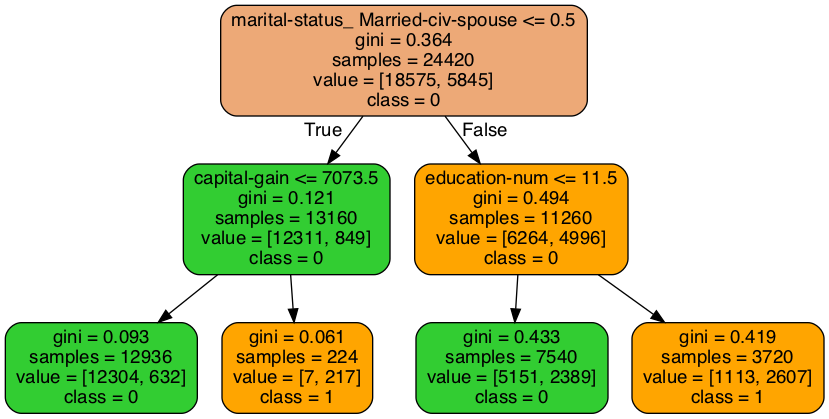

**📍 Root Node breakdown**

```
marital-status_ Married-civ-spouse <= 0.5  
gini = 0.364  
samples = 24420  
value = [18575, 5845]  
class = 0
```

**value = [ class0 (income_ >50K) / class1 (income_ <=50K) ]**

In [42]:
df_census["income_ >50K"].value_counts().sort_index().tolist()
# value (at root node) = [count_class0, count_class1]

[18575, 5845]

**samples**

In [43]:
# (rowCnt, colCnt)
# samples = 24421
df_census.shape

(24420, 93)

**class**

---

## 🤔 *SIDEBAR: What does class mean in a decision tree?*

In your dataset, the **class** refers to the **target variable you're trying to predict** — specifically:

---

### 🎯 **Target Column:**
```python
"income_ >50K"
```

### ✅ Class Definition:

| Value | Meaning             | Class Label |
|--------|----------------------|-------------|
| `0`    | Income ≤ 50K USD     | Class 0     |
| `1`    | Income > 50K USD     | Class 1     |

This is a **binary classification problem**, where the goal is to **predict whether a person earns more than $50K per year**, based on features like education, marital status, capital gains, etc.

---

### 🧠 So When the Tree Says:
```
class = 0
```
…it means:
> The model **predicts the person earns ≤50K**, because most samples at that node belong to class 0 (`income_ >50K = 0`).

---

### 🔍 Where Did This Come From?

In the original UCI **Adult Income Dataset**, the target was a string column:
- `<=50K`
- `>50K`

But your `census_cleaned.csv` has already converted this to:
```python
"income_ >50K"
→ 0 (for <=50K)
→ 1 (for >50K)
```

---

In [44]:
# calculating class
import numpy as np

value = [18575, 5845]
majority_class = np.argmax(value)  # returns 0
majority_class

np.int64(0)

---
### 🤔 SIDEBAR: Why Is `class = 0`?

The `class = 0` at the root node means:

> 💡 **Most of the samples at this node belong to class 0** (i.e., `income_ >50K == 0`, meaning ≤50K).

#### Breakdown:
- `value = [18575, 5845]`
  - **18,575** samples are from class 0 (≤50K)
  - **5,845** samples are from class 1 (>50K)
- Since **class 0 has the majority**, the node will **default to predicting 0** if no further splits are made.

### 📘 How `DecisionTreeClassifier` Picks Class at a Node

When you train a tree, `sklearn.tree.DecisionTreeClassifier` assigns:

- `value = [count_0, count_1]` for classification
- `class = argmax(value)` → the **most frequent class** in that node

```python
import numpy as np

value = [18575, 5845]
majority_class = np.argmax(value)  # returns 0
```

Hence, the root node is labeled:
```
class = 0
```

✅ It means: "If the tree stopped here, we'd predict class 0 for everyone."

---

**Gini score at root node**

In [45]:
# Class counts at the root node from your tree image
class_counts = [18575, 5845]  # [class 0 count, class 1 count]

# Step 1: Total samples
total = sum(class_counts)

# Step 2: Calculate class probabilities
p0 = class_counts[0] / total  # Probability of class 0
p1 = class_counts[1] / total  # Probability of class 1

# Step 3: Gini impurity formula
gini = 1 - (p0**2 + p1**2)

# Print result
print(f"Gini impurity at root node: {gini:.4f}")

Gini impurity at root node: 0.3641


### 🤔 *SIDEBAR: What is the score of 0.3641 telling you?*

**A Gini impurity of 0.3641 means that there's a 36.41% chance that a randomly chosen sample at the root would be incorrectly labeled if we predicted everyone as the majority class (class 0).**

---

### 🔍 What It Really Means:

- If you predict **everyone as class 0** (the majority), then **36.41% of the samples are actually class 1** and would be misclassified.
- So, Gini gives you a measure of **"how impure"** the node is — lower Gini means the node is closer to having all samples from a single class.

---


---

## 🤔 *SIDEBAR: What is Gini Score?*

Gini - This is fundamental to understanding how decision trees like CART (used by `sklearn`) make splits.

---

## 🔍 What Is Gini Impurity?

Gini impurity measures **how "mixed" the classes are** in a node. It helps the tree decide **where to split** the data.

### ✅ Formula for Gini Impurity:

For a binary classification:

$$
\text{Gini} = 1 - (p_0^2 + p_1^2)
$$

Where:
- \( p_0 \): Proportion of class 0 samples in the node
- \( p_1 \): Proportion of class 1 samples in the node

---

## 📦 At the Root Node

```
value = [18575, 5845]
total = 24420
```

### 🔢 Step-by-Step:

1. **Calculate class proportions**:
 $$
   p_0 = \frac{18575}{24420} \approx 0.7606,\quad p_1 = \frac{5845}{24420} \approx 0.2394
$$

2. **Plug into the Gini formula**:
   $$
   \text{Gini} = 1 - (0.7606^2 + 0.2394^2)
              = 1 - (0.5785 + 0.0573)
              = 1 - 0.6358 = 0.3642
   $$

3. **Rounded**:
   ```
   gini ≈ 0.364
   ```

---

### 📘 Interpretation

- **0.0 Gini** = perfect purity (all samples are same class)
- **0.5 Gini** = maximum impurity (50/50 class mix)

### So Here:
- Gini = 0.364 means the root node is **not perfectly pure**, but **mostly composed of class 0**
- The tree will try to **split the node** in a way that **reduces Gini** in the child nodes

---

**Moving on to other Nodes**

Great! Here's a detailed walkthrough of how **Gini impurity changes** through the tree split, using the exact dataset and the tree structure in your image.

---

# 🌳 Gini Impurity Walkthrough — Node by Node

| Node                        | Samples | Value (class 0, 1) | Gini     | Interpretation |
|----------------------------|---------|--------------------|----------|----------------|
| **Root**                   | 24,421  | [18,556, 5,865]    | **0.365** | Mixed, class 0 dominates |
| ├── **Left: marital ≤ 0.5**| 13,176  | [12,315, 861]      | **0.1222** | Mostly class 0 (unmarried → low income) |
| │   ├── Left: gain ≤ 7073  | 12,940  | [12,306, 634]      | **0.0932** | Very pure |
| │   └── Right: gain > 7073 | 236     | [9, 227]           | **0.0734** | Very pure but for class 1 (high gain → likely high income) |
| └── **Right: marital > 0.5**| 11,245 | [6,241, 5,004]     | **0.4939** | Highly mixed (married group) |
|     ├── Left: edu ≤ 11.5   | 7,573   | [5,115, 2,458]     | **0.4385** | Skewed toward class 0 |
|     └── Right: edu > 11.5  | 3,672   | [1,126, 2,546]     | **0.4252** | Skewed toward class 1 |

---

## 📈 What You’re Seeing

### ✅ Splitting helps reduce impurity:
- **Root:** moderately impure (Gini 0.365)
- After first split (marital-status), the left side becomes much **cleaner** (Gini 0.1222), and the right side remains **mixed** (Gini 0.4939)
- Further splits (capital-gain, education-num) continue to **purify nodes**

---

### 📘 Interpretation

- **Gini measures class impurity. Lower = better**.
- The decision tree **chooses splits that reduce Gini the most**.
- **Left branch** (unmarried + low gain) captures class 0 well.
- **Right branch** (married + high education) helps isolate class 1 earners.

---

Would you like a visual Gini drop chart or explanation of how the tree “decides” where to split based on this?

Perfect — let’s break it down:

---

# 🧠 How Does a Decision Tree “Decide” Where to Split?

The goal of a decision tree (like CART in `sklearn`) is to **split data at each node** such that the resulting **child nodes are purer** than the parent node.

It uses a **greedy algorithm**:  
> At each node, it looks at all features and all possible values, and **picks the split that reduces impurity the most**.

---

## 📉 Step-by-Step: Split Selection Using Gini Impurity

### 🔧 Formula for Gini Gain (Impurity Reduction)

$$
\text{Gini Gain} = G_{\text{parent}} - \left( \frac{n_L}{n} G_L + \frac{n_R}{n} G_R \right)
$$

Where:

- $G_{\text{parent}}$: Gini of current node
- $ G_L $, $ G_R $: Gini of left and right child after split
- $ n_L $, $ n_R $: Number of samples in left and right child
- $ n $: Total number of samples in parent

---

### ✅ In Your Tree (Root Node Example)

#### 1. **Evaluate All Candidate Features**  
e.g., "Should we split on: marital-status? capital-gain? education-num? age? etc."

#### 2. **Try All Reasonable Thresholds for Each Feature**  
e.g., for `marital-status_ Married-civ-spouse`:
- Try threshold `<= 0.5`

#### 3. **For Each Split, Calculate Gini Gain**

- **Before Split** (Root):
  - Gini = **0.365**
  - Value = [18556, 5865]

- **After Split on `marital-status_ Married-civ-spouse <= 0.5`**:
  - Left → Gini = **0.1222**, Value = [12315, 861]
  - Right → Gini = **0.4939**, Value = [6241, 5004]
  - Weighted Gini:
    $$
    = \frac{13176}{24421} \cdot 0.1222 + \frac{11245}{24421} \cdot 0.4939 \approx 0.2896
    $$
  - **Gini Gain**:
    $$
    = 0.365 - 0.2896 = 0.0754
    $$

This **0.0754 drop** is **the highest among all possible features and thresholds**, so the tree **chooses this split**.

---

### 🏁 Bottom Line:

> The tree **evaluates all possible splits**, picks the one with the **highest impurity reduction**, and repeats this process **recursively**.

---

Would you like me to plot how impurity drops from root ➜ children ➜ leaves visually with a Gini curve?

Here's the **visual chart** of how **Gini impurity changes** through the decision tree splits in your model:

---
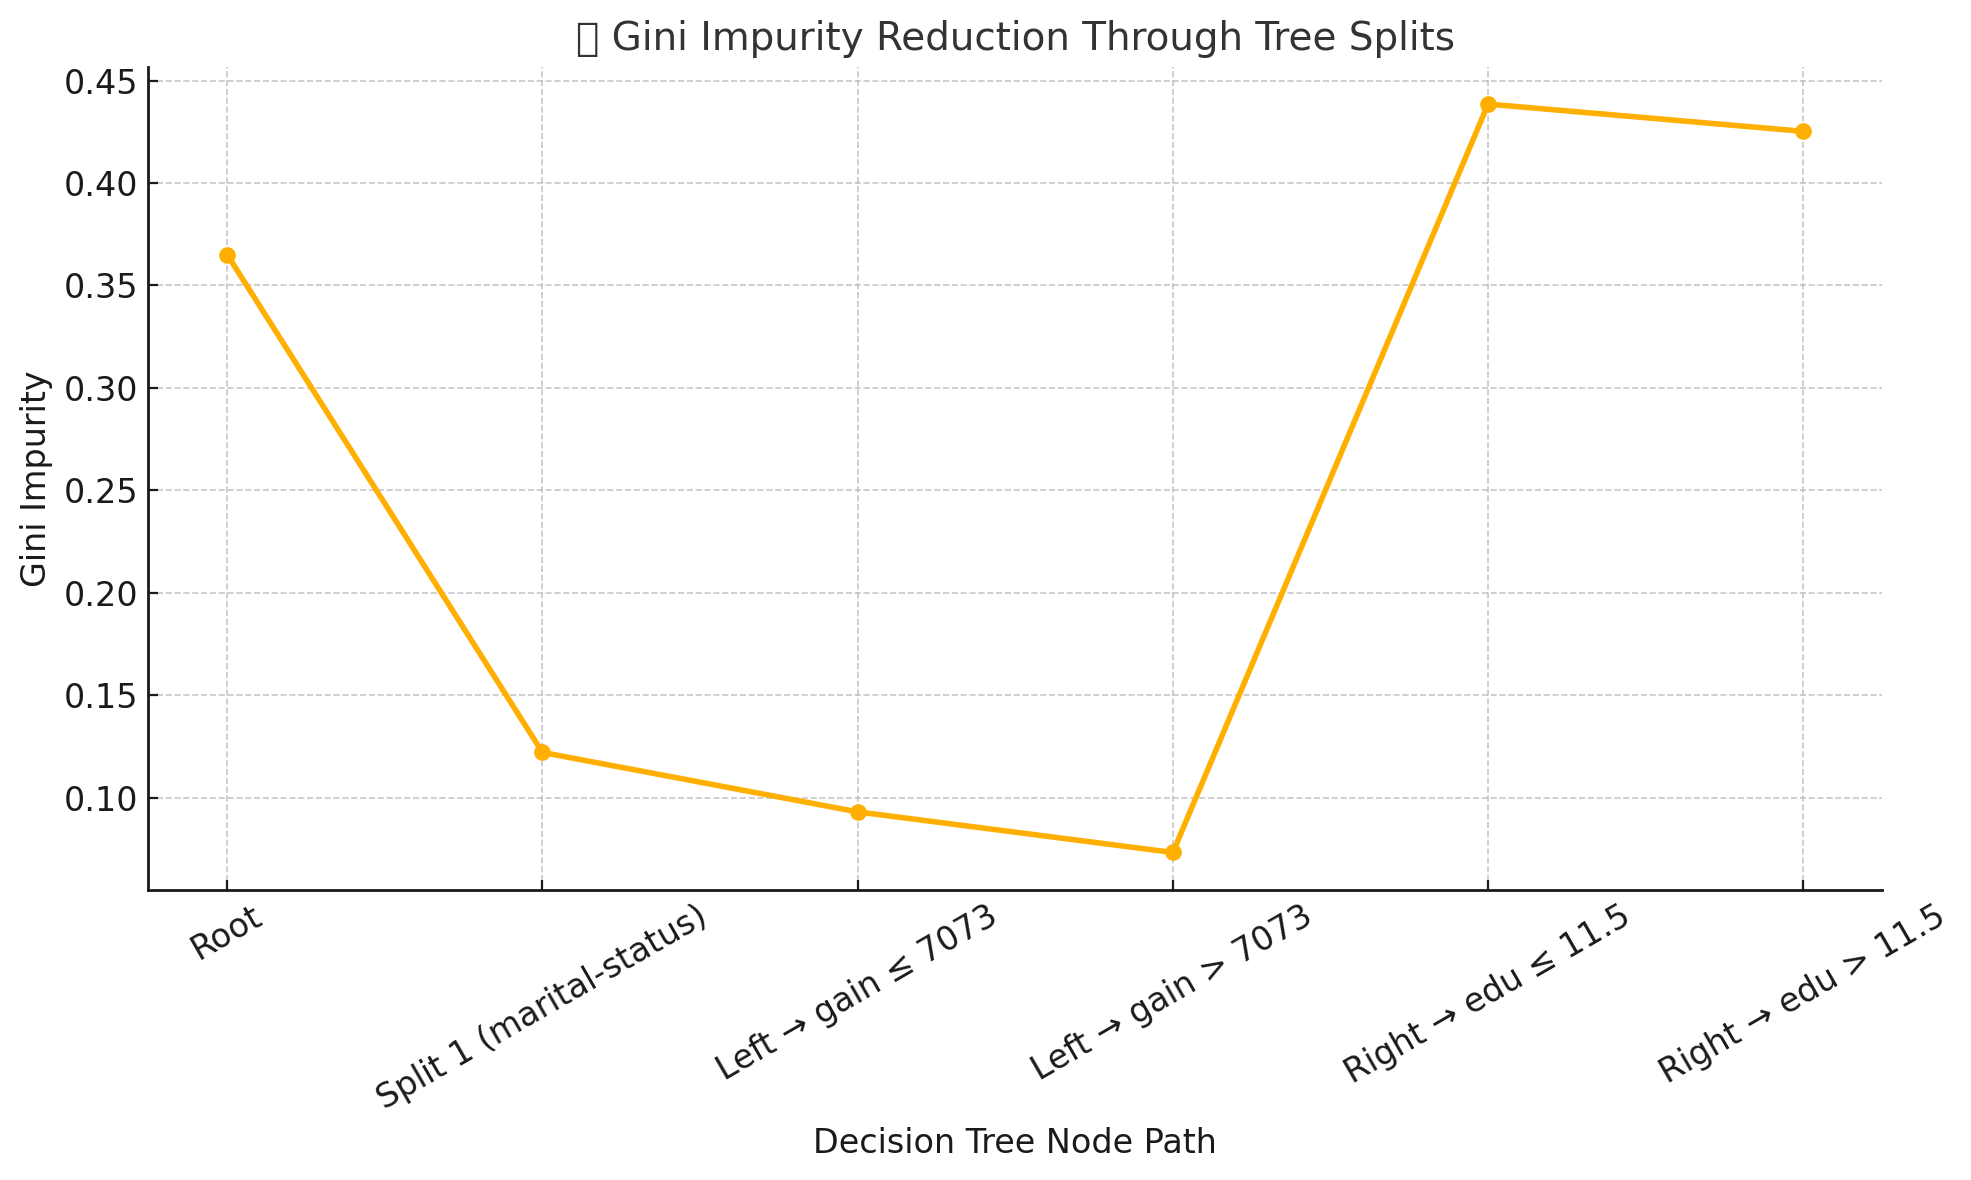
---

### 📉 Gini Impurity Reduction Path

- **Root node (no split)**: Gini = **0.365**
- **After marital-status split**: Gini drops to **0.1222** on the left (unmarried group)
- **Capital-gain split on left** brings Gini down further to **0.0932** and **0.0734**
- **Right branch (married group)** is more mixed: Gini around **0.4385** and **0.4252** even after education split

---

### 💡 Interpretation

- The **left branch** (unmarried + low capital-gain) becomes purer — the tree confidently classifies them as class 0.
- The **right branch** (married people) is harder to split cleanly — likely because both income classes exist there, requiring deeper logic or more features.

---

Let me know if you’d like the **weighted Gini gain formula** annotated over the graph or this analysis turned into a printable report or markdown file!